# <span style="color:blue;">OpenPTV-Python-GPU Feature Tutorial</span>

Please use the following link to run this notebook from Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ali-sh-96/openpiv-python-gpu/blob/main/openpiv_gpu/tutorials/openpiv_python_gpu_batching_tutorial.ipynb)

## <span style="color:blue;">Introduction</span>

This tutorial demonstrates the use of two feature extraction methods, adaptive Gaussian thresholding (AGT) and the Laplacian of Gaussian (LoG), in OpenPTV-Python-GPU for particle identification. The dataset consists of both synthetic and experimental image pairs. The synthetic images are vortex fields obtained from the PIV Challenge database (http://www.pivchallenge.org/pub/#b
), while the experimental images correspond to low-Reynolds-number separated flow over an airfoil, acquired in the Turbulence Research Lab at the University of Toronto. The synthetic images have a resolution of 512 by 512 pixels squared, whereas the experimental images are significantly larger, at 2052 by 4606 pixels square, approximately 13.9 MB each. Particle detection results are presented for both AGT and LoG methods on the synthetic dataset, while only the LoG method is applied to the experimental images.


In `openptv-python-gpu`, the feature extraction method is selected by setting `particle_method=`_`"agt"`_ or _`"log"`_. The adaptive Gaussian thresholding (AGT) used here is the same implementation as in OpenCV (https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html), and is not GPU-native. Simply put, AGT is a dynamic thresholding method that allows a local threshold to be used for image binarization, where the threshold value is a Gaussian-weighted sum of the neighbourhood values minus a constant C, determined by the parameter `threshold` in `openptv-python-gpu`. The value of `threshold` can be a real number or a tuple of two real values to specify the C constant for each image in the pair individually.

The Laplacian of Gaussian (LoG), on the other hand, is essentially a two-step spatial filter used for blob detection, combining Gaussian smoothing to reduce noise with the Laplacian operator to detect intensity changes. In `openptv-python-gpu`, setting `threshold` specifies the threshold level used to binarize the normalized intensity. In addition to the two parameters `particle_method` and `threshold`, a third parameter `particle_size` can be specified, which controls the size of the neighbourhood area in AGT or the value of sigma in LoG.

## <span style="color:blue;">Dependencies</span>

The `openptv-python-gpu` package primarily depends on `cupy` and `numpy`, although `cv2` is also required to use AGT particle detection. The choice of other libraries, such as those needed to load or save images, is left to the user. In this tutorial, opencv-python is used to load images, as it is also required by the package itself.

In [1]:
#@title Import the needed libraries
#@markdown Run this block to import the dependencies.
import sys
import os
from glob import glob
import cv2

import matplotlib.pyplot as plt
%matplotlib inline
import IPython.display as display

In [4]:
#@title Install `openptv-python-gpu`
#@markdown Run this block to install `openptv-python-gpu`.
!git clone https://github.com/ali-sh-96/openptv-python-gpu
openptv_path = "/content/openptv-python-gpu/"
sys.path.append(openptv_path)
from openptv_gpu.gpu_process import ptv_gpu

# Get the path to the tutorials folder.
tutorial_path = os.path.join(openptv_path, 'openptv_gpu/tutorials/')

fatal: destination path 'openptv-python-gpu' already exists and is not an empty directory.


## <span style="color:blue;">Separated Flow Test Case</span>

This section demonstrates the use of the module on a pair of experimental PIV images acquired in a study of low-Reynolds-number separated flow over an airfoil. The airfoil partially occludes the images. Although a mask could be applied to exclude the airfoil region from the analysis, the LoG method is inherently robust and produces few false detections in these areas. In contrast, the AGT method is more prone to false particle detection in the presence of such features and is therefore not shown here.

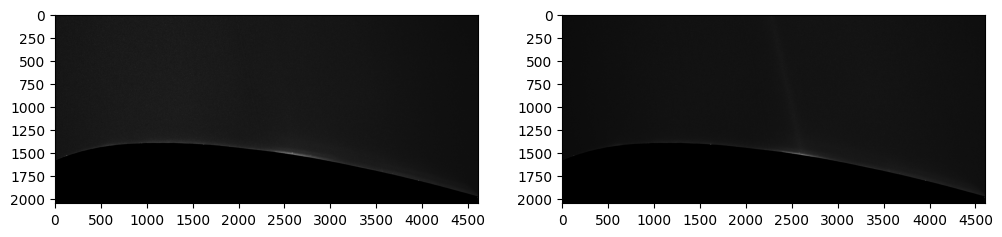

In [5]:
#@title Load the images
# Load the images.
test_dir = tutorial_path + "test2/"
tif_files = glob(os.path.join(test_dir + '*.tif'))

# Show the images.
frame_a = cv2.imread(tif_files[0], cv2.IMREAD_ANYDEPTH)
frame_b = cv2.imread(tif_files[1], cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
ht, wd = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, 2 * tick_step))
    ax.set_yticks(range(0, ht, tick_step))

plt.show()

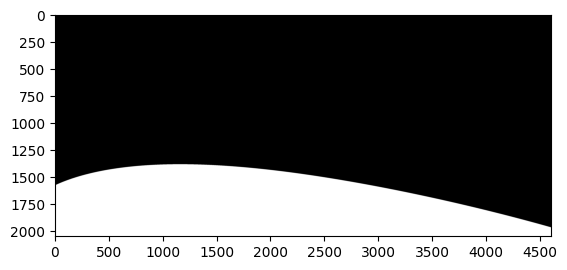

In [28]:
#@title Load the mask
# Load the airfoil mask.
mask = cv2.imread(test_dir + "airfoil_mask.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
plt.xticks(range(0, wd, 2 * tick_step))
plt.yticks(range(0, ht, tick_step))
plt.show()

In [35]:
#@title Feature extraction settings
#@markdown The shape of the images is `(2052, 4603)`.
frame_shape = (2052, 4603) #@param {type:"raw"}
particle_method = "log" #@param ["agt", "log"] {type:"string"}
subpixel_method = "gaussian" #@param ["gaussian", "centroid", "parabolic"] {type:"string"}
threshold = (0.05, 0.02) #@param {type:"raw"}
particle_size = (1, 1) #@param {type:"raw"}
mask = mask #@param {type:"raw"}

In [36]:
#@title Perform feature extraction
#@markdown Run this block to process the images.
# Initialize the process.
process = ptv_gpu(frame_shape,
                  particle_method=particle_method,
                  subpixel_method=subpixel_method,
                  threshold=threshold,
                  particle_size=particle_size,
                  mask=mask)

coords_a, coords_b = process.get_coords(frame_a, frame_b)

Note that it takes a long time to process the first image on the GPU since CUDA kernels need to be compiled before execution. Now that CUDA kernels are compiled, we may compare the GPU performance for different values of `batch_size`.

From the aforementioned experiment, it's evident that setting `batch_size=1000` resulted in improved computation time compared to batch_size=100. It's important to note that using `batch_size=`_`"full"`_ triggers a memory limitation error on the T4 GPU within Google Colab.

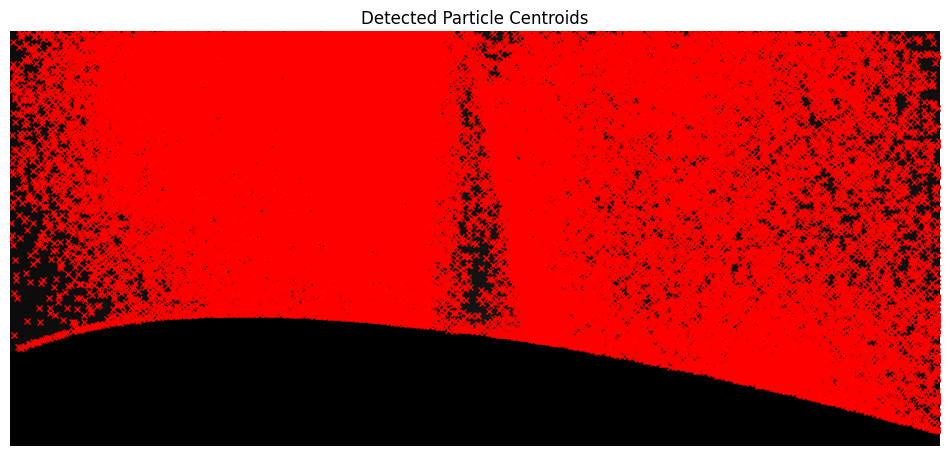

In [37]:
#@title Plot the results
def plot_detected_centroids(frame, coords, x_range=[0, frame_shape[1]], y_range=[0, frame_shape[0]]):
    """
    Plot detected particle centroids (from coords) on top of the frame.

    Parameters
    ----------
    frame : np.ndarray or cp.ndarray
        Input grayscale image
    coords : np.ndarray or cp.ndarray
        Coordinates of particle centers, shape (N, 2) as (y, x)
    color : str
        Marker color
    marker : str
        Matplotlib marker style (default 'x')
    markersize : float
        Size of the centroid marker
    """
    plt.figure(figsize=(12, 12))
    plt.imshow(frame, cmap='gray', origin='upper')

    if len(coords) > 0:
        plt.plot(coords[:, 1], coords[:, 0],
                  linestyle='none', marker='x',
                  color='red', markersize=4)

    plt.title("Detected Particle Centroids")
    plt.axis('off')
    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.gca().invert_yaxis()
    plt.show()


plot_detected_centroids(frame_b, coords_b, x_range=[0, frame_shape[1]], y_range=[0, frame_shape[0]])

## <span style="color:blue;">References</span>

> Raffel, M., Willert, C. E., & Kompenhans, J. (1998). Particle image velocimetry: a practical guide (Vol. 2, p. 218). Berlin: Springer.

> Scarano, F., & Riethmuller, M. L. (1999). Iterative multigrid approach in PIV image processing with discrete window offset. Experiments in Fluids, 26, 513-523.

> Meunier, P., & Leweke, T. (2003). Analysis and treatment of errors due to high velocity gradients in particle image velocimetry. Experiments in fluids, 35(5), 408-421.
    
> Garcia, D. (2010). Robust smoothing of gridded data in one and higher dimensions with missing values. Computational statistics & data analysis, 54(4), 1167-1178.

> Shirinzad, A., Jaber, K., Xu, K., & Sullivan, P. E. (2023). An Enhanced Python-Based Open-Source Particle Image Velocimetry Software for Use with Central Processing Units. Fluids, 8(11), 285.